In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [ ]:
np.random.seed(42)

n = 500

mileage_km = np.random.normal(60000, 25000, n)
age_years = np.random.randint(1, 15, n)
engine_size_L = np.random.uniform(1.0, 5.0, n)
price = np.random.normal(800000, 250000, n)

fuel_type = np.random.choice(
    ["Petrol", "Diesel", "Electric"],
    n
)

messy = pd.DataFrame({
    "mileage_km": mileage_km,
    "age_years": age_years,
    "engine_size_L": engine_size_L,
    "price": price,
    "fuel_type": fuel_type
})

In [ ]:
messy.loc[[10, 25, 50, 100], "mileage_km"] = np.nan
messy.loc[[15, 40, 80], "age_years"] = np.nan
messy.loc[[20, 60, 120], "engine_size_L"] = np.nan
messy.loc[[30, 70, 150], "price"] = np.nan
messy.loc[[35, 90, 180], "fuel_type"] = np.nan

messy.loc[[5, 6], "price"] = [5000000, 6000000]
messy.loc[[7, 8], "mileage_km"] = [300000, 350000]

messy.head()

,mileage_km,age_years,engine_size_L,price,fuel_type
0,72417.853825,10.0,4.260218,616828.952186,Electric
1,56543.392471,2.0,2.992363,926356.786656,Diesel
2,76192.213453,11.0,1.268702,949998.551981,Electric
3,98075.746410,8.0,2.620992,597481.728948,Diesel
4,54146.165632,11.0,2.989860,685390.764953,Electric


In [ ]:
print(messy.isna().sum())

mileage_km       4
age_years        3
engine_size_L    3
price            3
fuel_type        3
dtype: int64


In [ ]:
messy.describe()

,mileage_km,age_years,engine_size_L,price
count,496.000000,497.000000,497.000000,4.970000e+02
mean,61298.629981,7.269618,2.994161,8.267982e+05
std,29787.259230,4.039590,1.165356,3.872528e+05
min,-21031.683502,1.000000,1.000950,-3.790263e+04
25%,42492.314888,4.000000,2.002923,6.496041e+05
50%,60425.071669,7.000000,3.055983,8.203908e+05
75%,76215.355410,11.000000,3.977116,9.814417e+05
max,350000.000000,14.000000,4.997414,6.000000e+06


In [ ]:
num_cols = ["mileage_km", "age_years", "engine_size_L", "price"]
cat_cols = ["fuel_type"]

In [ ]:
num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

In [ ]:
clean = messy.copy()

clean[num_cols] = num_imputer.fit_transform(clean[num_cols])

clean[cat_cols] = cat_imputer.fit_transform(clean[cat_cols])

In [ ]:
print(clean.isna().sum())

mileage_km       0
age_years        0
engine_size_L    0
price            0
fuel_type        0
dtype: int64


In [ ]:
def cap_outliers_iqr(df, col, k=1.5):
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    df[col] = df[col].clip(lower, upper)
    return n_outliers

In [ ]:
for col in ["price", "mileage_km"]:
    print(
        col,
        "outliers capped:",
        cap_outliers_iqr(clean, col)
    )

price outliers capped: 5
mileage_km outliers capped: 6


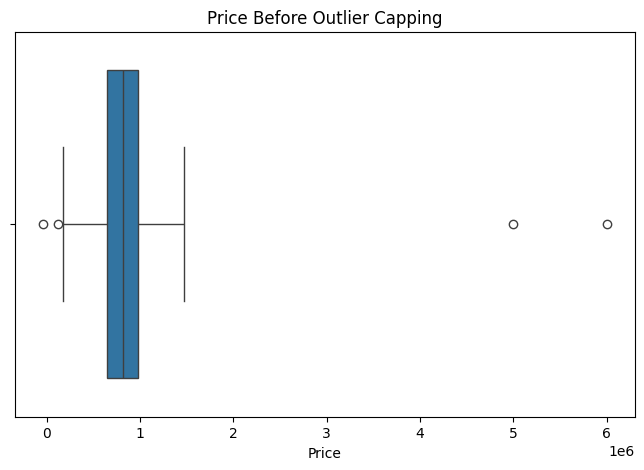

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=messy["price"])

plt.title("Price Before Outlier Capping")
plt.xlabel("Price")

plt.show()

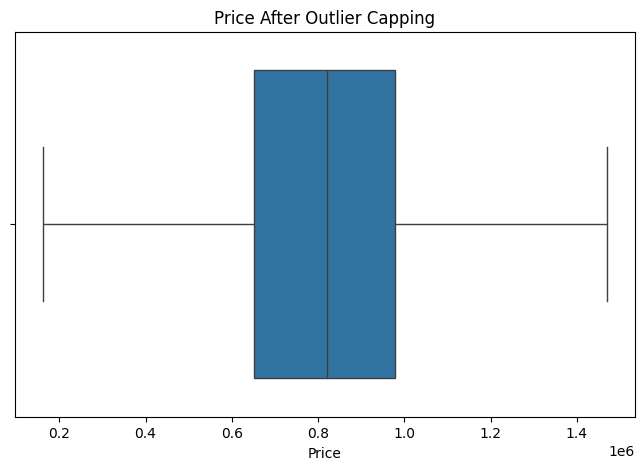

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=clean["price"])

plt.title("Price After Outlier Capping")
plt.xlabel("Price")

plt.show()

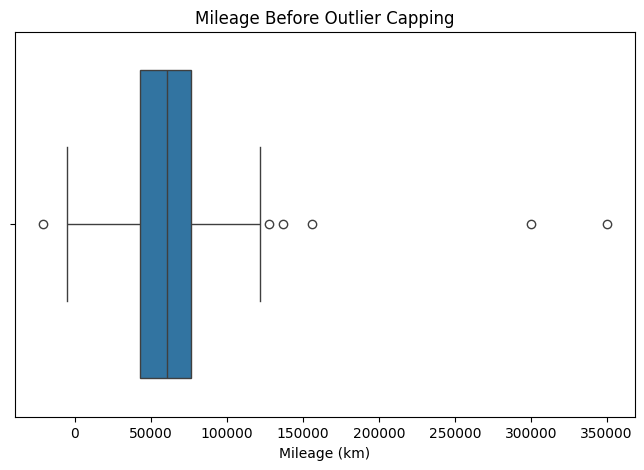

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=messy["mileage_km"])

plt.title("Mileage Before Outlier Capping")
plt.xlabel("Mileage (km)")

plt.show()

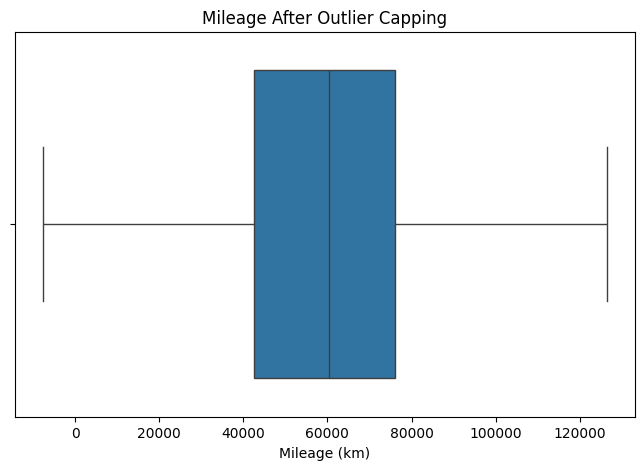

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=clean["mileage_km"])

plt.title("Mileage After Outlier Capping")
plt.xlabel("Mileage (km)")

plt.show()

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    drop="first"
)

In [ ]:
fuel_encoded = pd.DataFrame(
    encoder.fit_transform(clean[["fuel_type"]]),
    columns=encoder.get_feature_names_out(["fuel_type"])
)

fuel_encoded

,fuel_type_Electric,fuel_type_Petrol
0,1.0,0.0
1,0.0,0.0
2,1.0,0.0
3,0.0,0.0
4,1.0,0.0
...,...,...
495,0.0,0.0
496,0.0,0.0
497,1.0,0.0
498,1.0,0.0


In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_num = pd.DataFrame(
    scaler.fit_transform(clean[num_cols]),
    columns=num_cols
)

scaled_num.head()

,mileage_km,age_years,engine_size_L,price
0,0.490232,0.679019,1.090455,-0.786124
1,-0.159483,-1.309323,-0.001869,0.466335
2,0.644710,0.927561,-1.486894,0.561998
3,1.540366,0.181933,-0.321824,-0.864410
4,-0.257598,0.927561,-0.004026,-0.508699


In [ ]:
processed = pd.concat(
    [scaled_num, fuel_encoded],
    axis=1
)

In [ ]:
processed.head()

,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
0,0.490232,0.679019,1.090455,-0.786124,1.0,0.0
1,-0.159483,-1.309323,-0.001869,0.466335,0.0,0.0
2,0.644710,0.927561,-1.486894,0.561998,1.0,0.0
3,1.540366,0.181933,-0.321824,-0.864410,0.0,0.0
4,-0.257598,0.927561,-0.004026,-0.508699,1.0,0.0


In [ ]:
processed.shape

(500, 6)

In [ ]:
processed.describe()

,mileage_km,age_years,engine_size_L,price,fuel_type_Electric,fuel_type_Petrol
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,500.000000,500.000000
mean,2.966516e-16,7.105427e-17,2.664535e-16,-1.847411e-16,0.358000,0.342000
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,0.479892,0.474855
min,-2.786264e+00,-1.557866e+00,-1.717576e+00,-2.624861e+00,0.000000,0.000000
25%,-7.287446e-01,-8.122376e-01,-8.497281e-01,-6.417246e-01,0.000000,0.000000
50%,-6.127906e-04,-6.660945e-02,5.294343e-02,3.755906e-02,0.000000,0.000000
75%,6.429353e-01,9.275614e-01,8.441538e-01,6.803663e-01,1.000000,1.000000
max,2.700455e+00,1.673190e+00,1.725588e+00,2.663503e+00,1.000000,1.000000
